## Logistic Regression

In [20]:
from evaluate_classifier import evaluate_classifier

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [22]:
#importing the cmi_internet_cleaned_dataset
dataset = pd.read_csv("../dataset/cmi_internet_cleaned.csv")



In [23]:
#separating the features from the target variable, sii
X = dataset.drop("sii", axis=1)
y = dataset["sii"]

In [24]:
#show me the distribution of the target variable
print(y.value_counts())


sii
0    5476
1    1444
2     846
3      73
Name: count, dtype: int64


In [25]:
y.value_counts(normalize=True).sort_index()

sii
0    0.698558
1    0.184207
2    0.107922
3    0.009312
Name: proportion, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import StandardScaler

In [27]:
#do the classical train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [28]:
#standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression


In [30]:
#train the logistic regression model
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [31]:
#predict the test set
y_pred = logistic_model.predict(X_test_scaled)


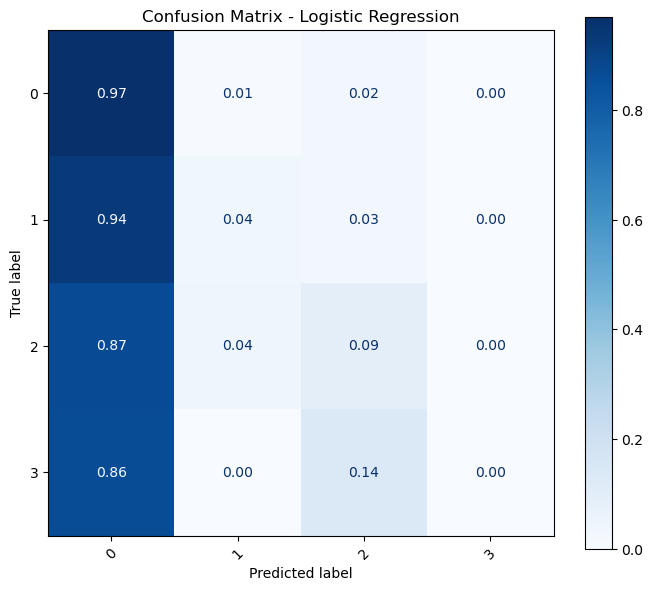

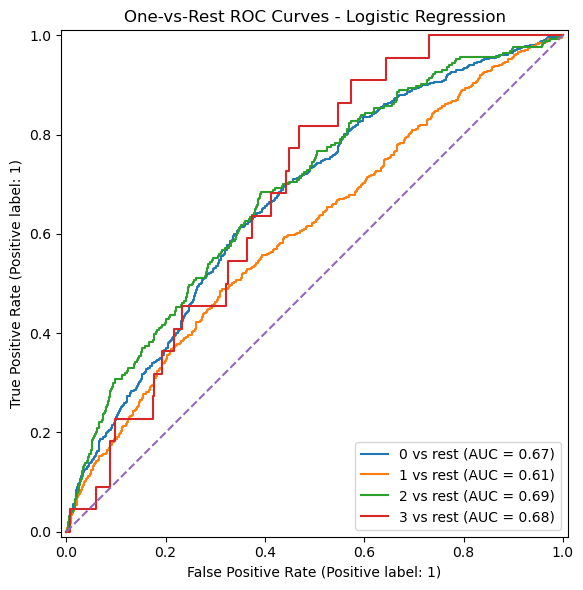

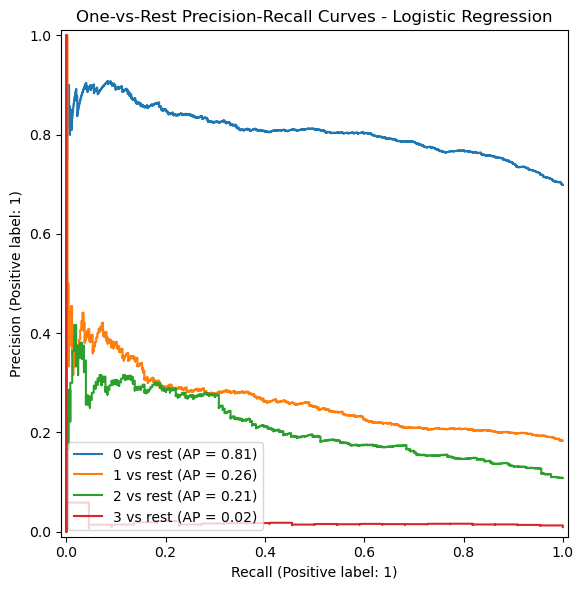


Classification report - Logistic Regression


,precision,recall,f1-score,support
0,0.712243,0.970177,0.821438,1643.000000
1,0.432432,0.036952,0.068085,433.000000
2,0.311688,0.094488,0.145015,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.694728,0.694728,0.694728,0.694728
macro avg,0.364091,0.275404,0.258634,2352.000000
weighted avg,0.610811,0.694728,0.602014,2352.000000


In [32]:
# evaluation of the model
results_logistic, report_logistic = evaluate_classifier(
    model=logistic_model,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)